In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud


In [2]:
# pip install textblob

In [3]:
# pip install wordcloud

In [4]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Download NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [6]:
df = pd.read_csv("3) Sentiment dataset.csv")  
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [7]:
# Display first few rows

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [8]:
# Drop unnecessary columns

df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], errors='ignore')

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)


In [10]:
# Handle missing values

df.dropna(subset=['Text'], inplace=True)
df['Sentiment'] = df['Sentiment'].fillna('Neutral')

In [11]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [12]:
# Check for missing values

print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


In [13]:
# Text Preprocessing

In [14]:
# Initialize tools

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [15]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and non-alphabetic words
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join tokens back into a single string
    return ' '.join(tokens)

In [16]:
# Apply preprocessing

df['Clean_Text'] = df['Text'].apply(preprocess_text)

In [17]:
# Sentiment Analysis

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [18]:
# Calculate polarity and sentiment

df['Polarity'] = df['Clean_Text'].apply(get_polarity)
df['Predicted_Sentiment'] = df['Polarity'].apply(get_sentiment_label)


In [20]:
# Display sample results

print("\nSentiment Analysis Completed!")
df[['Text', 'Predicted_Sentiment', 'Polarity']].head(10)



Sentiment Analysis Completed!


,Text,Predicted_Sentiment,Polarity
0,Enjoying a beautiful day at the park! ...,Positive,0.675000
1,Traffic was terrible this morning. ...,Negative,-1.000000
2,Just finished an amazing workout! 💪 ...,Positive,0.600000
3,Excited about the upcoming weekend getaway! ...,Positive,0.375000
4,Trying out a new recipe for dinner tonight. ...,Positive,0.136364
5,Feeling grateful for the little things in lif...,Negative,-0.187500
6,Rainy days call for cozy blankets and hot coc...,Positive,0.025000
7,The new movie release is a must-watch! ...,Positive,0.136364
8,Political discussions heating up on the timel...,Neutral,0.000000
9,Missing summer vibes and beach days. ...,Negative,-0.200000


In [ ]:
# Data Visualization

C:\Users\bhand\AppData\Local\Temp\ipykernel_35664\2669532696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Predicted_Sentiment', palette='Set2')


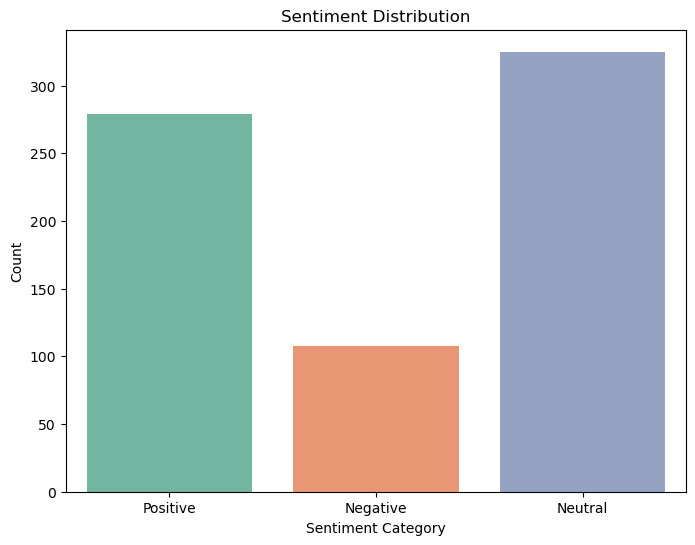

In [21]:
# Sentiment distribution

plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Predicted_Sentiment', palette='Set2')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.show()

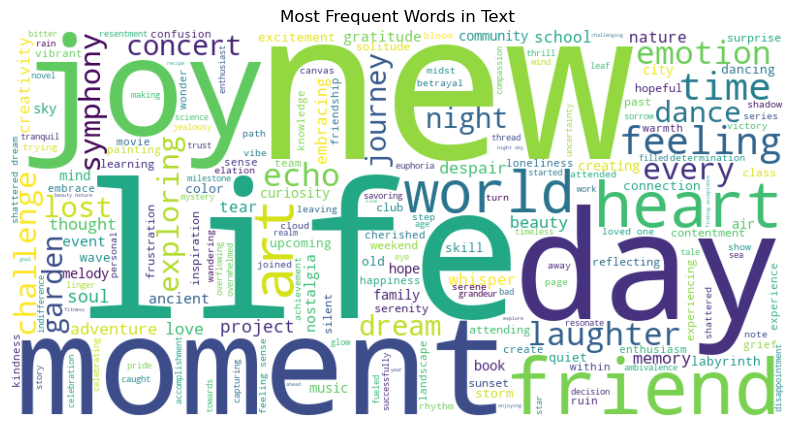

In [22]:
# WordCloud for all tweets

all_words = ' '.join(df['Clean_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Text")
plt.show()

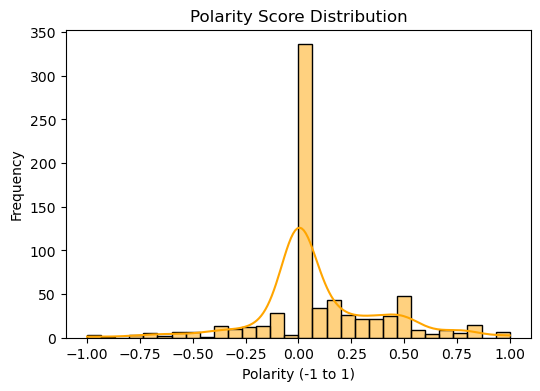

In [23]:
# Polarity distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Polarity'], bins=30, kde=True, color='orange')
plt.title("Polarity Score Distribution")
plt.xlabel("Polarity (-1 to 1)")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Insights of dataset

print(f"Total Records: {len(df)}\n")
print(df['Predicted_Sentiment'].value_counts())

print(f"\nAverage Polarity: {df['Polarity'].mean():.3f}")

Total Records: 712

Predicted_Sentiment
Neutral     325
Positive    279
Negative    108
Name: count, dtype: int64

Average Polarity: 0.093
